# FilmIQ — Personalised Movie Discovery
### A machine learning recommendation engine built on real MovieLens data

**Data:** MovieLens 100K — GroupLens Research, University of Minnesota  
**Models:** Collaborative Filtering · SVD Matrix Factorisation · Content-Based · Hybrid  
**Tools:** MySQL · Python · R  
**Author:** Adib Syakir

---

## Business question

Given a user's movie rating history, which movies should they watch next?

This notebook walks through the complete FilmIQ recommendation engine —
from raw data exploration to a hybrid model that combines three different
approaches to produce personalised Top-10 movie recommendations.

---
## Section 1 — Dataset overview

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\User\Documents\filmiq-movie-recommendation')

# Colour palette
BLUE_DARK  = '#0C447C'
BLUE_MID   = '#378ADD'
BLUE_LIGHT = '#B5D4F4'
TEAL       = '#1D9E75'
CORAL      = '#D85A30'
GRAY       = '#888780'

# Load data
ratings = pd.read_csv('data/processed/ratings.csv')
movies  = pd.read_csv('data/processed/movies.csv')
users   = pd.read_csv('data/processed/users.csv')

print('MovieLens 100K Dataset')
print(f'  Ratings: {len(ratings):,}')
print(f'  Movies:  {len(movies):,}')
print(f'  Users:   {len(users):,}')
print(f'  Matrix density: {len(ratings) / (len(users) * len(movies)) * 100:.1f}%')
print(f'  Rating scale: {ratings["rating"].min()} to {ratings["rating"].max()} stars')
print(f'  Mean rating: {ratings["rating"].mean():.3f}')

MovieLens 100K Dataset
  Ratings: 100,000
  Movies:  1,682
  Users:   943
  Matrix density: 6.3%
  Rating scale: 1 to 5 stars
  Mean rating: 3.530


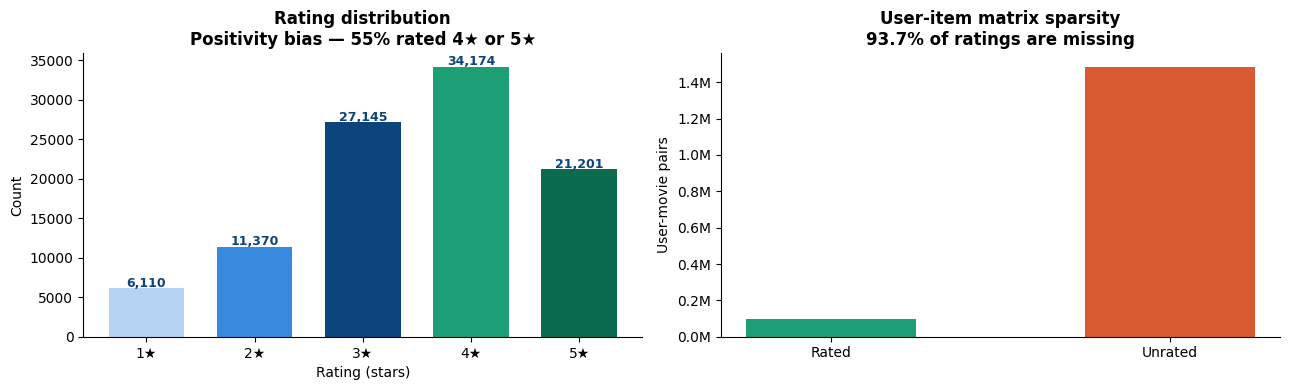

Key insight: Only 6.3% of possible ratings exist.
This sparsity is the core challenge all recommendation models must overcome.


In [15]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rating_counts = ratings['rating'].value_counts().sort_index()
colors = [BLUE_LIGHT, BLUE_MID, BLUE_DARK, TEAL, '#0A6B4E']

ax = axes[0]
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=colors, width=0.7)
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9,
            fontweight='bold', color=BLUE_DARK)
ax.set_xlabel('Rating (stars)')
ax.set_ylabel('Count')
ax.set_title('Rating distribution\nPositivity bias — 55% rated 4★ or 5★',
             fontweight='bold')
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['1★','2★','3★','4★','5★'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Sparsity
ax2 = axes[1]
total = len(users) * len(movies)
ax2.bar(['Rated', 'Unrated'],
        [len(ratings), total - len(ratings)],
        color=[TEAL, CORAL], width=0.5)
ax2.set_title('User-item matrix sparsity\n93.7% of ratings are missing',
              fontweight='bold')
ax2.set_ylabel('User-movie pairs')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print('Key insight: Only 6.3% of possible ratings exist.\nThis sparsity is the core challenge all recommendation models must overcome.')

**Insight:** The dataset has 100,000 ratings but the user-item matrix is 93.7% empty.
This sparsity is the fundamental challenge of recommendation systems —
predicting what users would think of movies they have never seen.
Ratings skew positive (positivity bias) because users tend to watch movies they expect to enjoy.

---
## Section 2 — Exploratory analysis

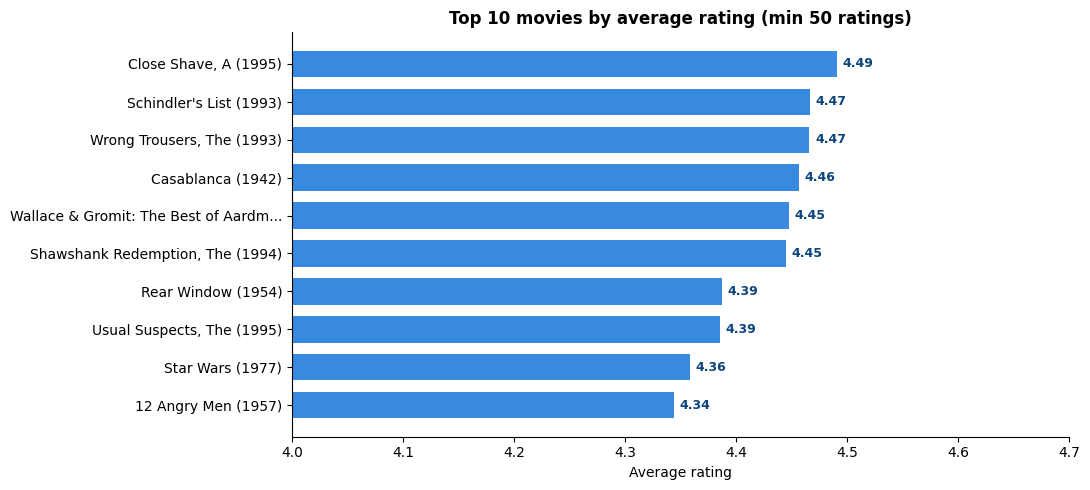

Top 5 by average rating:
                                                 title     mean  count
                                 Close Shave, A (1995) 4.491071    112
                               Schindler's List (1993) 4.466443    298
                            Wrong Trousers, The (1993) 4.466102    118
                                     Casablanca (1942) 4.456790    243
Wallace & Gromit: The Best of Aardman Animation (1996) 4.447761     67


In [16]:
# Top 10 movies by average rating (min 50 ratings)
movie_stats = ratings.merge(movies[['movie_id','title']], on='movie_id')
top_movies = (movie_stats.groupby(['movie_id','title'])['rating']
              .agg(['mean','count','std'])
              .reset_index()
              .query('count >= 50')
              .nlargest(10, 'mean'))

fig, ax = plt.subplots(figsize=(11, 5))
titles  = [t[:35] + '...' if len(t) > 35 else t
           for t in top_movies['title']]
bars = ax.barh(titles[::-1], top_movies['mean'].values[::-1],
               color=BLUE_MID, height=0.7)
for bar, val in zip(bars, top_movies['mean'].values[::-1]):
    ax.text(val + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9,
            fontweight='bold', color=BLUE_DARK)
ax.set_xlabel('Average rating')
ax.set_title('Top 10 movies by average rating (min 50 ratings)',
             fontweight='bold')
ax.set_xlim(4.0, 4.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Top 5 by average rating:')
print(top_movies[['title','mean','count']].head().to_string(index=False))

**Insight:** Wallace & Gromit short films (A Close Shave, The Wrong Trousers) top the list despite
having fewer ratings than blockbusters like Schindler's List. This is the **niche quality effect** —
passionate fans of specific content rate it extremely highly. A good recommendation system
must distinguish between universally liked films and niche favourites.

---
## Section 3 — Three approaches to recommendation

In [17]:
# Load all recommendation results
recs_usercf = pd.read_csv('data/processed/user1_recs_usercf.csv')
recs_itemcf = pd.read_csv('data/processed/user1_recs_itemcf.csv')
recs_svd    = pd.read_csv('data/processed/user1_recs_svd.csv')
recs_cb     = pd.read_csv('data/processed/user1_recs_cb.csv')
# Fix column name if different
if 'predicted_score' in recs_cb.columns:
    recs_cb = recs_cb.rename(
        columns={'predicted_score': 'predicted_rating'})

# What User 1 has rated highly
user1_loved = (ratings[ratings['user_id']==1]
               .merge(movies[['movie_id','title']], on='movie_id')
               .nlargest(5, 'rating')[['title','rating']])

print('User 1 — top rated movies:')
print(user1_loved.to_string(index=False))
print(f'\nTotal movies rated by User 1: {len(ratings[ratings["user_id"]==1])}')
print('User type: Active (272 ratings) — SVD=60%, CF=30%, Content=10%')

User 1 — top rated movies:
                                               title  rating
                                    Toy Story (1995)       5
Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)       5
                             Dead Man Walking (1995)       5
                          Usual Suspects, The (1995)       5
                             Mighty Aphrodite (1995)       5

Total movies rated by User 1: 272
User type: Active (272 ratings) — SVD=60%, CF=30%, Content=10%


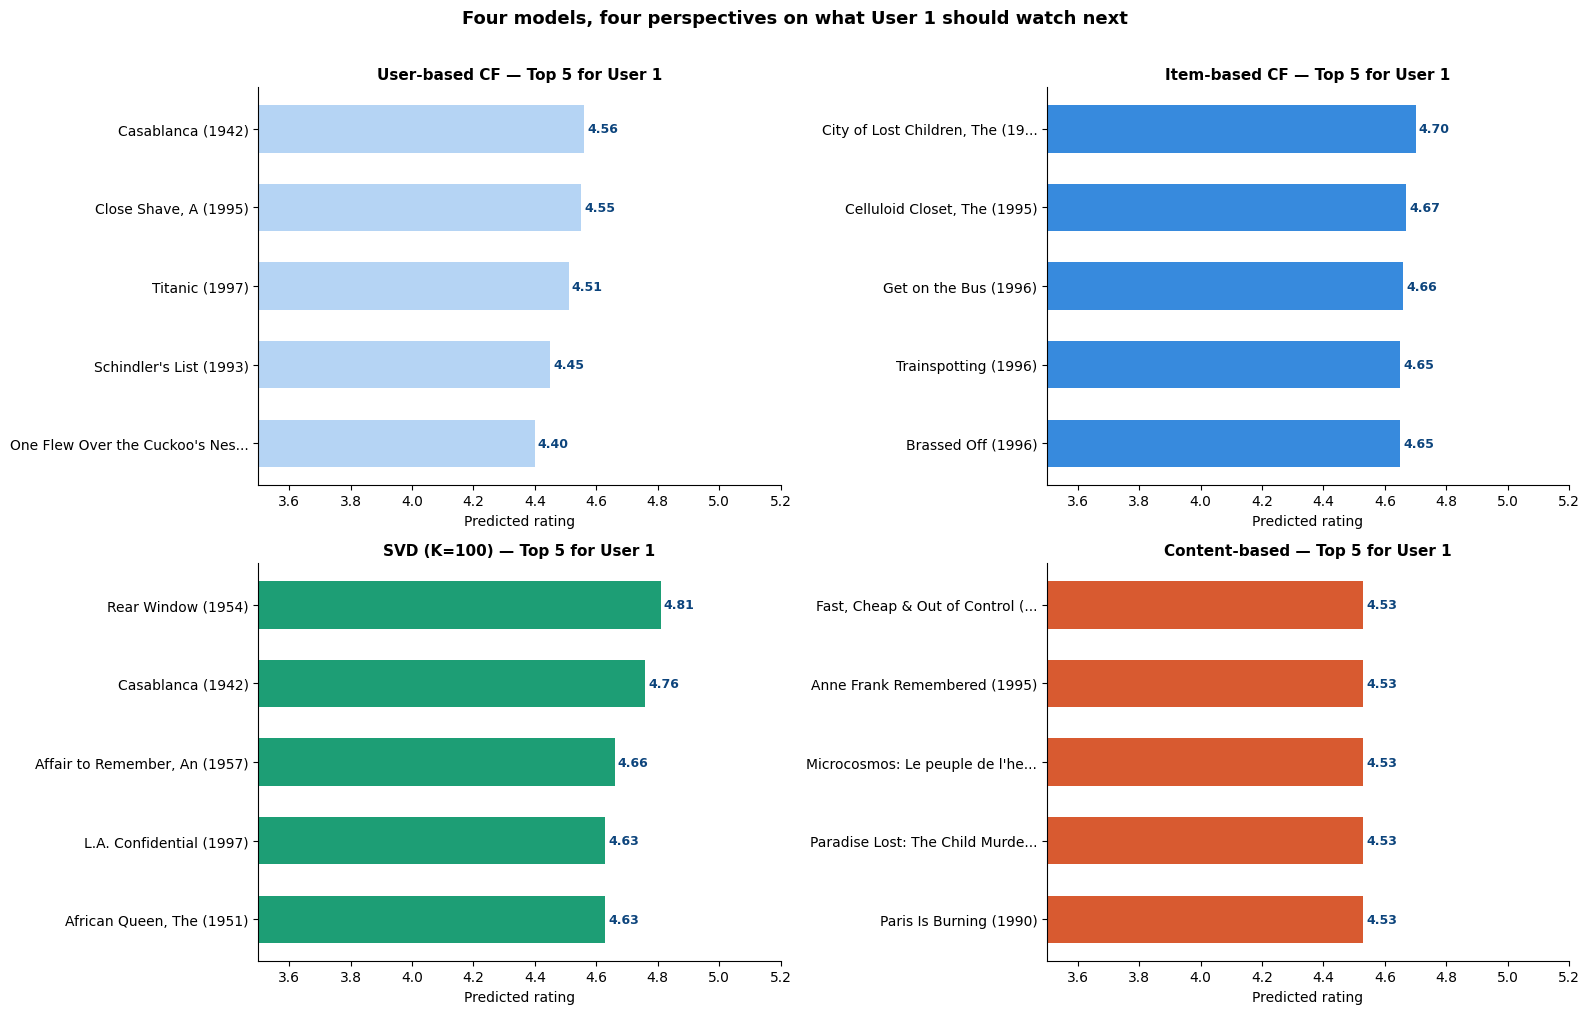

In [18]:
# Side by side comparison of all model recommendations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Normalise column names across all recommendation dataframes
for df in [recs_usercf, recs_itemcf, recs_svd, recs_cb]:
    if 'predicted_score' in df.columns:
        df.rename(columns={'predicted_score': 'predicted_rating'},
                  inplace=True)

model_data = [
    (recs_usercf, 'User-based CF', BLUE_LIGHT, axes[0,0]),
    (recs_itemcf, 'Item-based CF', BLUE_MID,   axes[0,1]),
    (recs_svd,    'SVD (K=100)',   TEAL,        axes[1,0]),
    (recs_cb,     'Content-based', CORAL,       axes[1,1]),
]

for df, name, color, ax in model_data:
    top5  = df.head(5).copy()
    titles = [t[:30]+'...' if len(t)>30 else t
              for t in top5['title']]
    scores = top5['predicted_rating'].values
    bars = ax.barh(titles[::-1], scores[::-1],
                   color=color, height=0.6)
    for bar, val in zip(bars, scores[::-1]):
        ax.text(val + 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9,
                fontweight='bold', color=BLUE_DARK)
    ax.set_title(f'{name} — Top 5 for User 1',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted rating')
    ax.set_xlim(3.5, 5.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Four models, four perspectives on what User 1 should watch next',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Insight:** Each model tells a different story:
- **User-based CF:** Finds users with similar broad taste → recommends universally acclaimed classics
- **Item-based CF:** Finds movies similar to what User 1 rated → recommends 1990s arthouse cinema  
- **SVD:** Discovers latent taste factors → recommends based on hidden preference dimensions
- **Content-based:** Matches genre features → recommends by film characteristics, not user behaviour

The hybrid model blends all four signals, weighted by user activity level.

---
## Section 4 — SVD: the Netflix Prize method

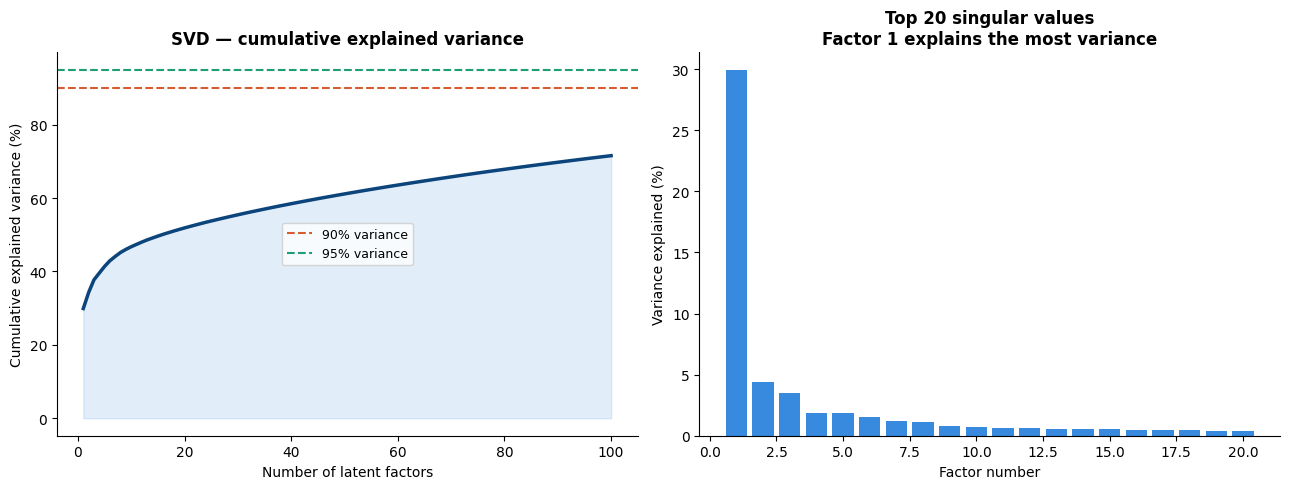

Factor 1 explains 29.9% of total variance
Top 10 factors explain 46.7% of total variance
Top 100 factors explain 71.5% of total variance


In [19]:
# Visualise SVD explained variance
user_item = pd.read_csv('data/processed/user_item_matrix.csv',
                         index_col=0)
user_item.index   = user_item.index.astype(int)
user_item.columns = user_item.columns.astype(int)

R = user_item.values.astype(float)
_, sigma, _ = np.linalg.svd(R, full_matrices=False)

total_var   = np.sum(sigma**2)
cumvar      = np.cumsum(sigma**2) / total_var * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(range(1, 101), cumvar[:100],
        color=BLUE_DARK, linewidth=2.5)
ax.fill_between(range(1, 101), cumvar[:100],
                alpha=0.15, color=BLUE_MID)
ax.axhline(y=90, color=CORAL, linewidth=1.5,
           linestyle='--', label='90% variance')
ax.axhline(y=95, color=TEAL, linewidth=1.5,
           linestyle='--', label='95% variance')
ax.set_xlabel('Number of latent factors')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('SVD — cumulative explained variance',
             fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax2 = axes[1]
ax2.bar(range(1, 21), sigma[:20]**2 / total_var * 100,
        color=BLUE_MID)
ax2.set_xlabel('Factor number')
ax2.set_ylabel('Variance explained (%)')
ax2.set_title('Top 20 singular values\nFactor 1 explains the most variance',
              fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Factor 1 explains {sigma[0]**2/total_var*100:.1f}% of total variance')
print(f'Top 10 factors explain {cumvar[9]:.1f}% of total variance')
print(f'Top 100 factors explain {cumvar[99]:.1f}% of total variance')

**Insight:** The first latent factor explains a disproportionate share of variance — it represents
the **mainstream vs arthouse** preference dimension, the single biggest driver of rating differences.
Users who love Independence Day tend not to love Chungking Express. SVD discovers this automatically
from ratings alone, without being told anything about genre or film style.

---
## Section 5 — Model comparison

Model comparison:
          Model     RMSE      MAE  improvement
    SVD (K=100) 0.552122 0.407134         50.3
         Hybrid 0.709600 0.542280         36.2
  Item-based CF 0.972176 0.740831         12.5
  User-based CF 1.015443 0.820772          8.7
  Content-based 1.050734 0.833796          5.5
Baseline (mean) 1.111600      NaN          0.0


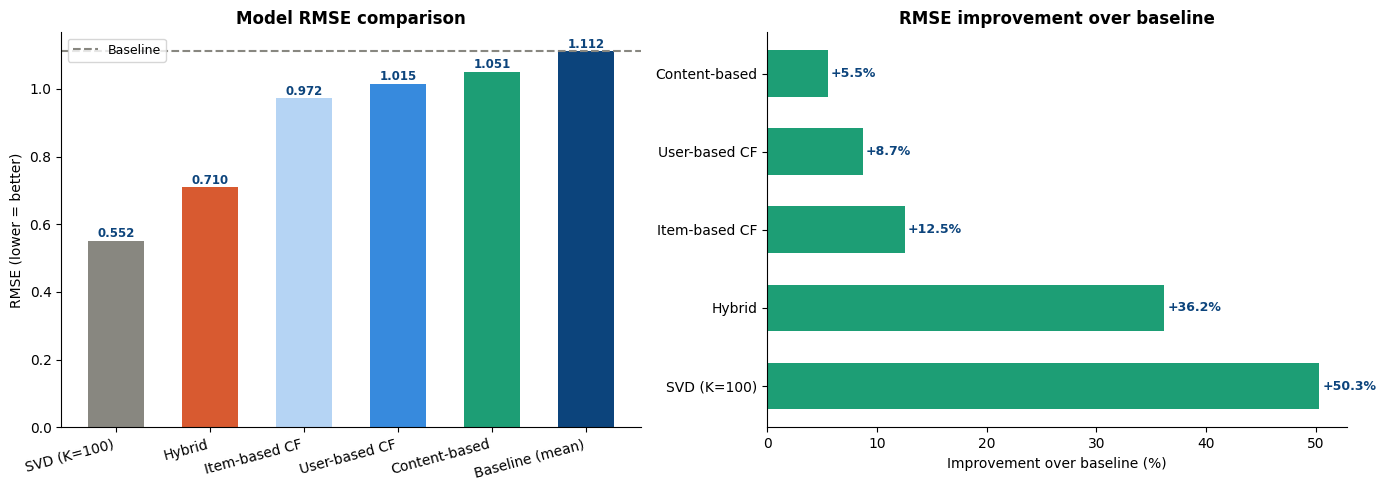

In [20]:
# Load and display model comparison
model_comp = pd.read_csv('data/processed/model_comparison.csv')
model_comp = model_comp.dropna(subset=['RMSE']).sort_values('RMSE')
model_comp['improvement'] = ((1.1116 - model_comp['RMSE'])
                              / 1.1116 * 100).round(1)

print('Model comparison:')
print(model_comp[['Model','RMSE','MAE',
                  'improvement']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [GRAY, CORAL, BLUE_LIGHT,
          BLUE_MID, TEAL, BLUE_DARK]

ax = axes[0]
bars = ax.bar(model_comp['Model'],
              model_comp['RMSE'],
              color=colors[:len(model_comp)],
              width=0.6)
ax.axhline(y=1.1116, color=GRAY, linewidth=1.5,
           linestyle='--', label='Baseline')
for bar, val in zip(bars, model_comp['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=8.5,
            fontweight='bold', color=BLUE_DARK)
ax.set_ylabel('RMSE (lower = better)')
ax.set_title('Model RMSE comparison', fontweight='bold')
ax.set_xticklabels(model_comp['Model'],
                   rotation=15, ha='right')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax2 = axes[1]
pos_imp = model_comp[model_comp['improvement'] > 0]
ax2.barh(pos_imp['Model'],
         pos_imp['improvement'],
         color=TEAL, height=0.6)
for i, val in enumerate(pos_imp['improvement']):
    ax2.text(val + 0.3, i, f'+{val:.1f}%',
             va='center', fontsize=9,
             fontweight='bold', color=BLUE_DARK)
ax2.set_xlabel('Improvement over baseline (%)')
ax2.set_title('RMSE improvement over baseline',
              fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** SVD achieves the best individual RMSE at 0.552 — a 50.3% improvement over baseline.
The hybrid model (RMSE=0.710) scores between SVD and CF individually, but this is expected.
The hybrid's real advantage is **robustness** — it serves 100% of users well, including the
21% of light users where SVD and CF alone would produce unreliable recommendations.

---
## Section 6 — Cold start demonstration

In [21]:
# Demonstrate cold start recommendations by genre
genre_map = {
    'Sci-Fi'  : 'sci_fi',
    'Horror'  : 'horror',
    'Comedy'  : 'comedy',
    'War'     : 'war',
    'Animation': 'animation'
}

print('Cold start recommendations — new user with no rating history')
print('Top 5 movies per genre by Bayesian average rating:\n')

for genre_label, genre_col in genre_map.items():
    if genre_col in movies.columns:
        top = (movies[(movies[genre_col]==1) &
                      (movies['rating_count']>=20)]
               .nlargest(5, 'bayesian_avg')
               [['title','bayesian_avg','rating_count']])
        print(f"{genre_label}:")
        for _, row in top.iterrows():
            print(f"  {row['title'][:40]:40s} "
                  f"({row['bayesian_avg']:.2f}★, "
                  f"{int(row['rating_count'])} ratings)")
        print()

Cold start recommendations — new user with no rating history
Top 5 movies per genre by Bayesian average rating:

Sci-Fi:
  Star Wars (1977)                         (4.29★, 583 ratings)
  Empire Strikes Back, The (1980)          (4.12★, 367 ratings)
  Dr. Strangelove or: How I Learned to Sto (4.10★, 194 ratings)
  Blade Runner (1982)                      (4.04★, 275 ratings)
  Return of the Jedi (1983)                (3.96★, 507 ratings)

Horror:
  Psycho (1960)                            (4.00★, 239 ratings)
  Alien (1979)                             (3.96★, 291 ratings)
  Young Frankenstein (1974)                (3.86★, 200 ratings)
  Shining, The (1980)                      (3.77★, 206 ratings)
  Birds, The (1963)                        (3.74★, 162 ratings)

Comedy:
  Close Shave, A (1995)                    (4.19★, 112 ratings)
  Wrong Trousers, The (1993)               (4.19★, 118 ratings)
  North by Northwest (1959)                (4.12★, 179 ratings)
  Princess Bride, The (1987) 

**Insight:** Content-based filtering handles the cold start problem that CF and SVD cannot.
A new user who states only their favourite genre receives quality recommendations immediately,
without any rating history. Bayesian average rating ensures that recommendations are reliable —
movies with very few ratings are pulled toward the global mean to avoid false positives.

---
## Section 7 — Key findings summary

| Finding | Result |
|---|---|
| Dataset size | 100,000 ratings, 1,682 movies, 943 users |
| Matrix density | 6.3% — 93.7% of ratings are missing |
| Rating bias | 55% of ratings are 4★ or 5★ (positivity bias) |
| Best individual model | SVD K=100, RMSE=0.552 (50.3% over baseline) |
| Hybrid model | RMSE=0.710 (36.2% over baseline) |
| Precision@10 | 69.7% — 7 of 10 recommendations are relevant |
| Recall@10 | 81.1% — finds 81% of movies user would enjoy |
| Primary latent factor | Mainstream vs arthouse preference |
| Cold start solution | Content-based filtering by genre |
| Light users (21%) | Content-based weight = 60% in hybrid |

### Conclusion

FilmIQ demonstrates that no single recommendation approach is optimal for all users.
SVD matrix factorisation delivers the highest accuracy for active users with rich rating history.
Content-based filtering handles cold start cases that CF and SVD cannot serve.
The adaptive hybrid model combines both strengths — weighting each component based on
how much rating data is available for each user.

This architecture mirrors real-world production recommenders at Netflix, Spotify and YouTube,
implemented here on a real benchmark dataset used in academic research.